# Analysis of German Credit Data using Data Mining Techniques

Sample Data:
    Age         Job  CreditAmount  Duration Housing  Risk
0   25     Skilled          5000        12     Own  Good
1   45   Unskilled         10000        24    Rent   Bad
2   35  Management          7000        18     Own  Good
3   50     Skilled         12000        36     Own   Bad
4   23   Unskilled          3000        10    Rent  Good
5   40  Management          8000        20     Own  Good
6   60     Skilled         15000        48     Own   Bad
7   48  Management         11000        30    Rent   Bad
8   33     Skilled          6000        15     Own  Good
9   27   Unskilled          4000        12    Rent  Good

Decision Tree Accuracy: 1.0
SVM Accuracy: 1.0
Confusion Matrix:
 [[0 0]
 [0 2]]


C:\Users\prash\AppData\Local\Temp\ipykernel_2000\4140217918.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


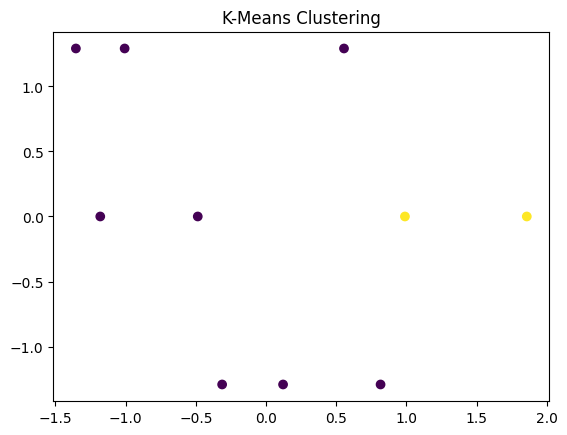

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

# -------------------------------
# Sample Dataset (German Credit-like)
# -------------------------------
data = {
    "Age": [25, 45, 35, 50, 23, 40, 60, 48, 33, 27],
    "Job": ["Skilled", "Unskilled", "Management", "Skilled", "Unskilled",
            "Management", "Skilled", "Management", "Skilled", "Unskilled"],
    "CreditAmount": [5000, 10000, 7000, 12000, 3000, 8000, 15000, 11000, 6000, 4000],
    "Duration": [12, 24, 18, 36, 10, 20, 48, 30, 15, 12],
    "Housing": ["Own", "Rent", "Own", "Own", "Rent", "Own", "Own", "Rent", "Own", "Rent"],
    "Risk": ["Good", "Bad", "Good", "Bad", "Good", "Good", "Bad", "Bad", "Good", "Good"]
}

# Download from UCI or Kaggle and load CSV
# df = pd.read_csv("german_credit_data.csv")

df = pd.DataFrame(data)

print("Sample Data:\n", df)

# -------------------------------
# Data Preprocessing
# -------------------------------
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop("Risk", axis=1)
y = df["Risk"]

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# -------------------------------
# 1. Classification
# -------------------------------
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt, labels=[0,1]))

# -------------------------------
# 2. Clustering
# -------------------------------
kmeans = KMeans(n_clusters=2, random_state=0)
clusters = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.show()